Images : 118
Neurons: 39209
Animate fraction: 0.5338983050847458


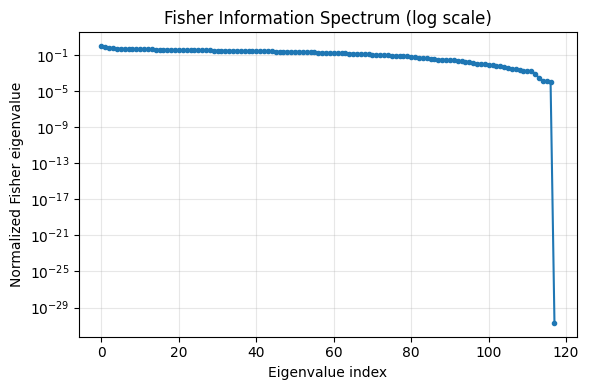

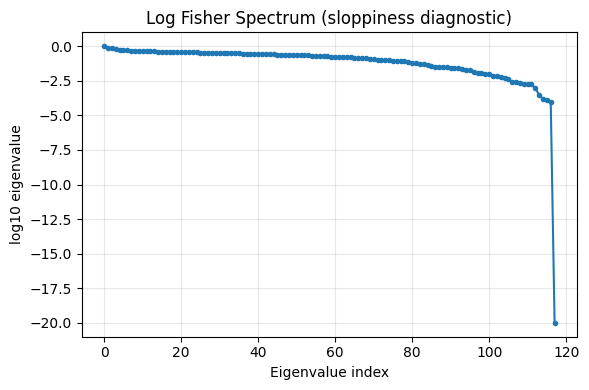

Eigenvalues span ~ 19.999999999991434 orders of magnitude


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# PATHS
# ============================================================
VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================
vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images :", vit.shape[0])
print("Neurons:", R.shape[1])

# Animate / inanimate heuristic
top1   = np.argmax(vit, axis=1)
y_true = (top1 <= 397).astype(int)
print("Animate fraction:", y_true.mean())

# ============================================================
# STANDARDIZE NEURAL DATA
# ============================================================
scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(R)

# ============================================================
# FIT LOGISTIC REGRESSION
# ============================================================
clf = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000
)
clf.fit(X, y_true)

# Predicted probabilities
p = clf.predict_proba(X)[:, 1]

# ============================================================
# FISHER SPECTRUM VIA WEIGHTED SVD
# ============================================================
# Z = sqrt(W) X
w = np.sqrt(p * (1 - p))[:, None]
Z = w * X

# SVD of Z (cheap: images x neurons)
U, S, Vt = np.linalg.svd(Z, full_matrices=False)

# Fisher eigenvalues = singular values squared
fisher_eigs = S**2

# Normalize (as in Gutenkunst paper)
fisher_eigs /= fisher_eigs.max()

# ============================================================
# PLOTS
# ============================================================
plt.figure(figsize=(6, 4))
plt.semilogy(fisher_eigs, '.-')
plt.xlabel("Eigenvalue index")
plt.ylabel("Normalized Fisher eigenvalue")
plt.title("Fisher Information Spectrum (log scale)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Log-spacing check
log_eigs = np.log10(fisher_eigs + 1e-20)
plt.figure(figsize=(6, 4))
plt.plot(log_eigs, '.-')
plt.xlabel("Eigenvalue index")
plt.ylabel("log10 eigenvalue")
plt.title("Log Fisher Spectrum (sloppiness diagnostic)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# QUICK NUMERICAL SUMMARY
# ============================================================
print("Eigenvalues span ~",
      np.log10(fisher_eigs.max()) - np.log10(fisher_eigs.min() + 1e-20),
      "orders of magnitude")



In [2]:
k = 5  # ignore last 5
span = np.log10(fisher_eigs[:-k].max()) - np.log10(fisher_eigs[:-k].min() + 1e-20)
print("Span excluding last", k, ":", span, "decades")


Span excluding last 5 : 3.0340216228068986 decades


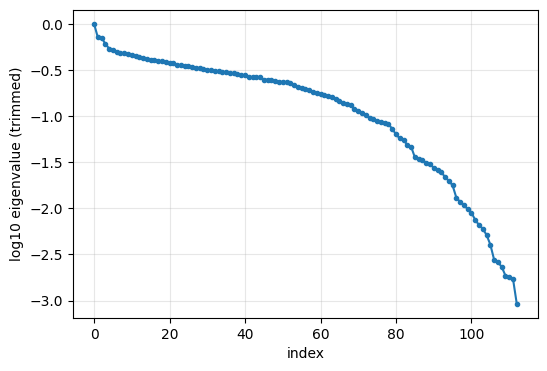

In [3]:
plt.figure(figsize=(6,4))
plt.plot(np.log10(fisher_eigs[:-5] + 1e-20), '.-')
plt.xlabel("index")
plt.ylabel("log10 eigenvalue (trimmed)")
plt.grid(alpha=0.3)
plt.show()


In [4]:
lam = fisher_eigs[:-5]
d_eff = (lam.sum()**2) / (np.sum(lam**2) + 1e-20)
print("Effective Fisher dimension (trimmed):", d_eff)


Effective Fisher dimension (trimmed): 64.91093302783104


Images : 118
Neurons: 39209
Animate fraction: 0.5338983050847458

=== REAL ===
Effective Fisher dimension (trimmed): 64.91093302783102
Top-10 eigen mass (trimmed): 0.24698819048986725
Span (trimmed) decades: 3.0340216228068986

Running shuffles...
  25/200
  50/200
  75/200
  100/200
  125/200
  150/200
  175/200
  200/200

=== NULL TEST ===
Null d_eff: mean 67.84425586624886 std 11.39989459192178
Null top-k mass: mean 0.26242760660262154 std 0.042867499507609055
Empirical p (d_eff <= real) [real more concentrated]: 0.40298507462686567
Empirical p (top-10 mass >= real) [real stiffer top end]: 0.5671641791044776


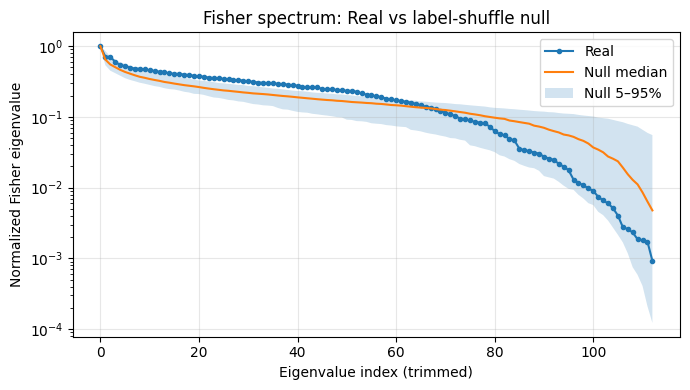

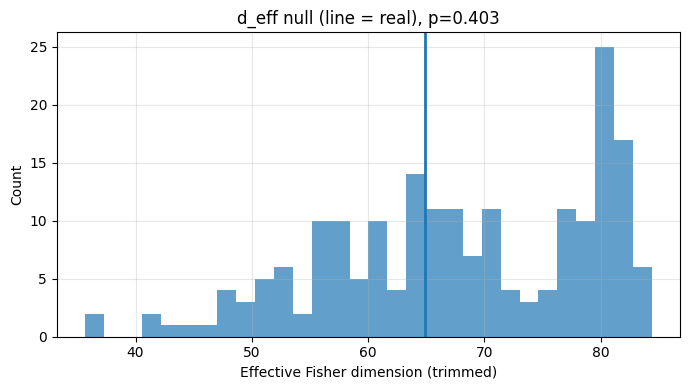

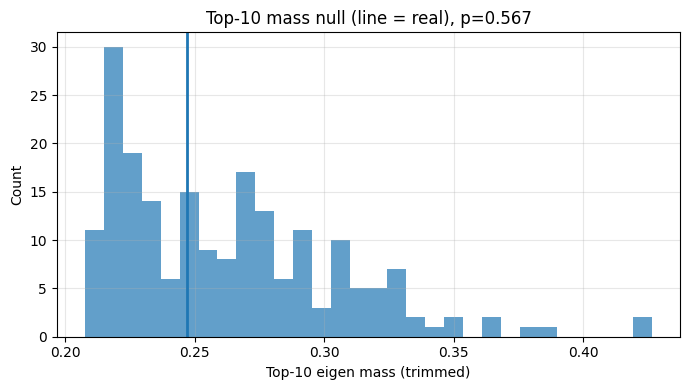

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# PATHS
# ============================================================
VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# SETTINGS
# ============================================================
N_SHUFFLES = 200
TRIM_TAIL  = 5      # ignore last few near-zero modes
TOPK       = 10     # stiffness proxy: how much mass in top-k eigenvalues
C          = 1.0
MAX_ITER   = 5000
SEED       = 0

rng = np.random.default_rng(SEED)

# ============================================================
# LOAD DATA
# ============================================================
vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images :", vit.shape[0])
print("Neurons:", R.shape[1])

top1   = np.argmax(vit, axis=1)
y_true = (top1 <= 397).astype(int)
print("Animate fraction:", y_true.mean())

# ============================================================
# STANDARDIZE X ONCE
# ============================================================
scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(R)

# ============================================================
# HELPERS
# ============================================================
def fisher_eigs_from_lr(X, y, C=1.0, max_iter=5000):
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=max_iter
    )
    clf.fit(X, y)
    p = clf.predict_proba(X)[:, 1]
    w = np.sqrt(p * (1 - p))[:, None]
    Z = w * X
    # Fisher eigenvalues = singular values^2 of Z
    S = np.linalg.svd(Z, full_matrices=False, compute_uv=False)
    lam = S**2
    lam = lam / (lam.max() + 1e-30)
    return lam

def effective_dim(lam):
    lam = np.asarray(lam)
    return (lam.sum()**2) / (np.sum(lam**2) + 1e-30)

def topk_mass(lam, k=10):
    lam = np.asarray(lam)
    return lam[:k].sum() / (lam.sum() + 1e-30)

# ============================================================
# REAL
# ============================================================
lam_real_full = fisher_eigs_from_lr(X, y_true, C=C, max_iter=MAX_ITER)
lam_real = lam_real_full[:-TRIM_TAIL] if TRIM_TAIL > 0 else lam_real_full

d_eff_real = effective_dim(lam_real)
m_topk_real = topk_mass(lam_real, TOPK)

print("\n=== REAL ===")
print("Effective Fisher dimension (trimmed):", d_eff_real)
print(f"Top-{TOPK} eigen mass (trimmed):", m_topk_real)
print("Span (trimmed) decades:",
      np.log10(lam_real.max()+1e-30) - np.log10(lam_real.min()+1e-30))

# ============================================================
# NULL (SHUFFLES)
# ============================================================
d_eff_null = np.zeros(N_SHUFFLES)
m_topk_null = np.zeros(N_SHUFFLES)
lam_null_mat = np.zeros((N_SHUFFLES, len(lam_real)))

print("\nRunning shuffles...")
for b in range(N_SHUFFLES):
    y_shuf = rng.permutation(y_true)
    lam_b_full = fisher_eigs_from_lr(X, y_shuf, C=C, max_iter=MAX_ITER)
    lam_b = lam_b_full[:-TRIM_TAIL] if TRIM_TAIL > 0 else lam_b_full

    lam_null_mat[b] = lam_b
    d_eff_null[b] = effective_dim(lam_b)
    m_topk_null[b] = topk_mass(lam_b, TOPK)

    if (b+1) % 25 == 0:
        print(f"  {b+1}/{N_SHUFFLES}")

# Empirical p-values (one-sided, direction depends on hypothesis)
# Often: real should have *more concentration* => smaller d_eff, larger top-k mass
p_deff_small = (np.sum(d_eff_null <= d_eff_real) + 1) / (N_SHUFFLES + 1)
p_topk_large = (np.sum(m_topk_null >= m_topk_real) + 1) / (N_SHUFFLES + 1)

print("\n=== NULL TEST ===")
print("Null d_eff: mean", d_eff_null.mean(), "std", d_eff_null.std())
print("Null top-k mass: mean", m_topk_null.mean(), "std", m_topk_null.std())
print("Empirical p (d_eff <= real) [real more concentrated]:", p_deff_small)
print(f"Empirical p (top-{TOPK} mass >= real) [real stiffer top end]:", p_topk_large)

# ============================================================
# PLOTS
# ============================================================
# Spectrum envelope
q_lo, q_hi = np.quantile(lam_null_mat, [0.05, 0.95], axis=0)
q_med = np.quantile(lam_null_mat, 0.50, axis=0)

plt.figure(figsize=(7,4))
plt.semilogy(lam_real, '.-', label='Real')
plt.semilogy(q_med, '-', label='Null median')
plt.fill_between(np.arange(len(lam_real)), q_lo, q_hi, alpha=0.2, label='Null 5–95%')
plt.xlabel("Eigenvalue index (trimmed)")
plt.ylabel("Normalized Fisher eigenvalue")
plt.title("Fisher spectrum: Real vs label-shuffle null")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Histograms for summary stats
plt.figure(figsize=(7,4))
plt.hist(d_eff_null, bins=30, alpha=0.7)
plt.axvline(d_eff_real, linewidth=2)
plt.xlabel("Effective Fisher dimension (trimmed)")
plt.ylabel("Count")
plt.title(f"d_eff null (line = real), p={p_deff_small:.3g}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(m_topk_null, bins=30, alpha=0.7)
plt.axvline(m_topk_real, linewidth=2)
plt.xlabel(f"Top-{TOPK} eigen mass (trimmed)")
plt.ylabel("Count")
plt.title(f"Top-{TOPK} mass null (line = real), p={p_topk_large:.3g}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== REAL (EMPIRICAL FISHER) ===
Effective Fisher dimension: 43.32479614793233
Top-10 eigen mass: 0.36115923789004695

Running empirical Fisher shuffles...
  25/200
  50/200
  75/200
  100/200
  125/200
  150/200
  175/200
  200/200

=== NULL TEST (EMPIRICAL FISHER) ===
Null d_eff: mean 45.419089456209576 std 17.528594000345826
Null top-k mass: mean 0.37734562067070826 std 0.11199919361804891
Empirical p (d_eff <= real): 0.48756218905472637
Empirical p (top-10 mass >= real): 0.48756218905472637


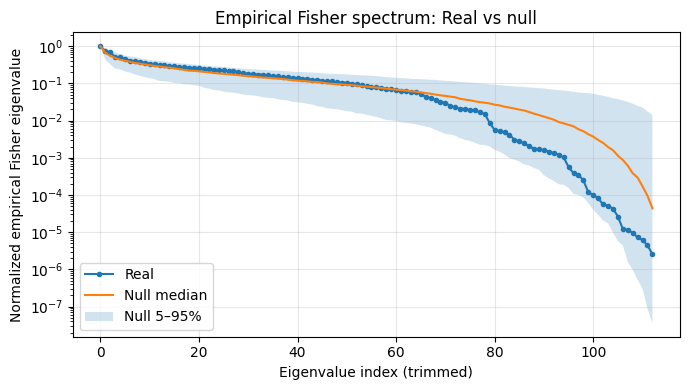

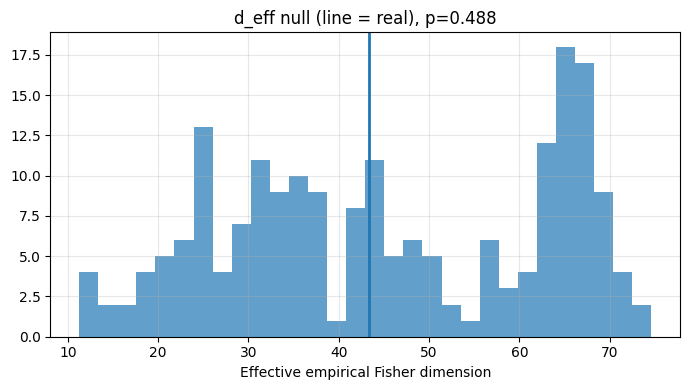

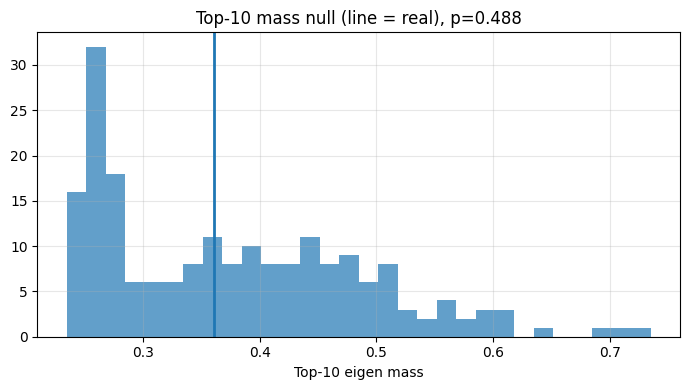

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# SETTINGS
# ============================================================
N_SHUFFLES = 200
TRIM_TAIL  = 5
TOPK       = 10
C          = 1.0
MAX_ITER   = 5000
SEED       = 0

rng = np.random.default_rng(SEED)

# ============================================================
# LOAD DATA (assumes already loaded earlier)
# ============================================================
# vit, R, y_true already in memory
# X already standardized earlier
# If not, re-run the preprocessing block from before

# ============================================================
# HELPERS
# ============================================================
def empirical_fisher_eigs_from_lr(X, y, C=1.0, max_iter=5000):
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=max_iter
    )
    clf.fit(X, y)

    p = clf.predict_proba(X)[:, 1]
    r = (y - p)[:, None]          # residuals

    Z = r * X                     # empirical Fisher factor
    S = np.linalg.svd(Z, full_matrices=False, compute_uv=False)
    lam = S**2
    lam = lam / (lam.max() + 1e-30)
    return lam

def effective_dim(lam):
    lam = np.asarray(lam)
    return (lam.sum()**2) / (np.sum(lam**2) + 1e-30)

def topk_mass(lam, k=10):
    return lam[:k].sum() / (lam.sum() + 1e-30)

# ============================================================
# REAL
# ============================================================
lam_real_full = empirical_fisher_eigs_from_lr(X, y_true, C=C, max_iter=MAX_ITER)
lam_real = lam_real_full[:-TRIM_TAIL]

d_eff_real = effective_dim(lam_real)
m_topk_real = topk_mass(lam_real, TOPK)

print("\n=== REAL (EMPIRICAL FISHER) ===")
print("Effective Fisher dimension:", d_eff_real)
print(f"Top-{TOPK} eigen mass:", m_topk_real)

# ============================================================
# NULL
# ============================================================
d_eff_null = np.zeros(N_SHUFFLES)
m_topk_null = np.zeros(N_SHUFFLES)
lam_null_mat = np.zeros((N_SHUFFLES, len(lam_real)))

print("\nRunning empirical Fisher shuffles...")
for b in range(N_SHUFFLES):
    y_shuf = rng.permutation(y_true)
    lam_b_full = empirical_fisher_eigs_from_lr(X, y_shuf, C=C, max_iter=MAX_ITER)
    lam_b = lam_b_full[:-TRIM_TAIL]

    lam_null_mat[b] = lam_b
    d_eff_null[b] = effective_dim(lam_b)
    m_topk_null[b] = topk_mass(lam_b, TOPK)

    if (b+1) % 25 == 0:
        print(f"  {b+1}/{N_SHUFFLES}")

p_deff_small = (np.sum(d_eff_null <= d_eff_real) + 1) / (N_SHUFFLES + 1)
p_topk_large = (np.sum(m_topk_null >= m_topk_real) + 1) / (N_SHUFFLES + 1)

print("\n=== NULL TEST (EMPIRICAL FISHER) ===")
print("Null d_eff: mean", d_eff_null.mean(), "std", d_eff_null.std())
print("Null top-k mass: mean", m_topk_null.mean(), "std", m_topk_null.std())
print("Empirical p (d_eff <= real):", p_deff_small)
print(f"Empirical p (top-{TOPK} mass >= real):", p_topk_large)

# ============================================================
# PLOTS
# ============================================================
q_lo, q_hi = np.quantile(lam_null_mat, [0.05, 0.95], axis=0)
q_med = np.quantile(lam_null_mat, 0.50, axis=0)

plt.figure(figsize=(7,4))
plt.semilogy(lam_real, '.-', label='Real')
plt.semilogy(q_med, '-', label='Null median')
plt.fill_between(np.arange(len(lam_real)), q_lo, q_hi, alpha=0.2, label='Null 5–95%')
plt.xlabel("Eigenvalue index (trimmed)")
plt.ylabel("Normalized empirical Fisher eigenvalue")
plt.title("Empirical Fisher spectrum: Real vs null")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(d_eff_null, bins=30, alpha=0.7)
plt.axvline(d_eff_real, linewidth=2)
plt.xlabel("Effective empirical Fisher dimension")
plt.title(f"d_eff null (line = real), p={p_deff_small:.3g}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(m_topk_null, bins=30, alpha=0.7)
plt.axvline(m_topk_real, linewidth=2)
plt.xlabel(f"Top-{TOPK} eigen mass")
plt.title(f"Top-{TOPK} mass null (line = real), p={p_topk_large:.3g}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Images: 118 Neurons: 39209 Animate frac: 0.5338983050847458


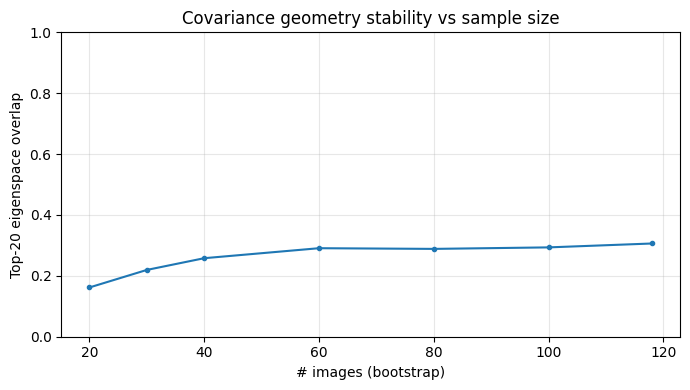

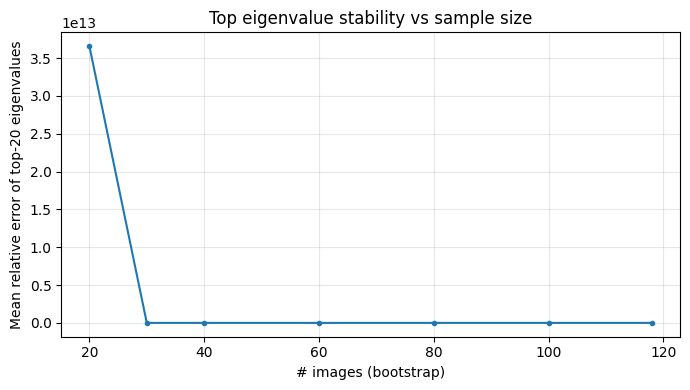

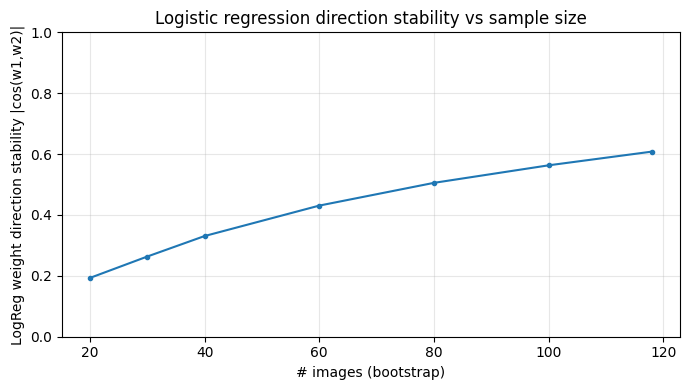

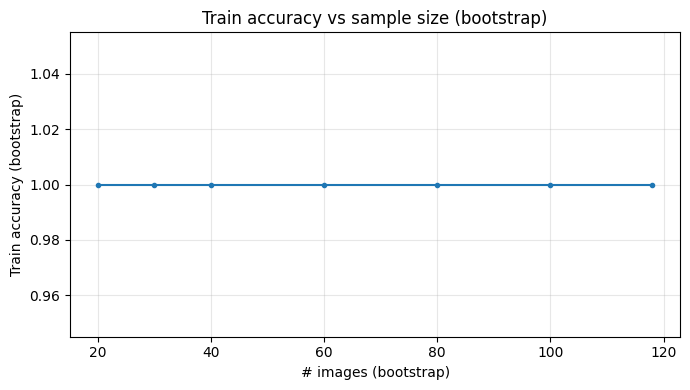

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# LOAD YOUR DATA
# =========================
VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'

vit = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']     # (images, 1000)
R   = np.load(NEURAL_PATH).T                                     # (images, neurons)

top1   = np.argmax(vit, axis=1)
y_true = (top1 <= 397).astype(int)

n_images, n_neurons = R.shape
print("Images:", n_images, "Neurons:", n_neurons, "Animate frac:", y_true.mean())

# Standardize features (important for covariance comparisons)
X = StandardScaler().fit_transform(R)

rng = np.random.default_rng(0)

# =========================
# HELPERS
# =========================
def top_subspace(Z, k=20):
    # Z: (m, p), mean-centered assumed (X is standardized already)
    # Return top-k right singular vectors (p x k) spanning top covariance directions
    # Cov eigenvectors in feature-space correspond to V from SVD of Z
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    V = Vt.T[:, :k]
    eigs = (S[:k]**2) / (Z.shape[0]-1)  # top-k covariance eigenvalues
    return V, eigs

def subspace_overlap(Va, Vb):
    # Va,Vb: (p,k) orthonormal bases. Return mean squared canonical correlation
    M = Va.T @ Vb
    # singular values = cosines of principal angles
    s = np.linalg.svd(M, compute_uv=False)
    return np.mean(s**2)

def lr_fit_return_w(Xm, ym, C=1.0):
    clf = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=5000)
    clf.fit(Xm, ym)
    w = clf.coef_.ravel()
    # normalize to compare directions
    w = w / (np.linalg.norm(w) + 1e-12)
    acc = clf.score(Xm, ym)
    return w, acc

# =========================
# MAIN DIAGNOSTIC LOOP
# =========================
M_grid = [20, 30, 40, 60, 80, 100, 118]   # #images used per resample
K_EIG  = 20                                # top eigendirections to test
N_REP  = 200                               # resample pairs per M

subspace_scores = []
eig_relerrs = []
w_cos = []
train_accs = []

for m in M_grid:
    ss = []
    ee = []
    wc = []
    ta = []
    for _ in range(N_REP):
        idx1 = rng.choice(n_images, size=m, replace=True)  # bootstrap images
        idx2 = rng.choice(n_images, size=m, replace=True)

        Z1 = X[idx1]
        Z2 = X[idx2]

        V1, e1 = top_subspace(Z1, k=K_EIG)
        V2, e2 = top_subspace(Z2, k=K_EIG)

        ss.append(subspace_overlap(V1, V2))
        ee.append(np.mean(np.abs(e1 - e2) / (np.abs(e1) + 1e-12)))

        # logistic regression stability on same resamples
        w1, a1 = lr_fit_return_w(Z1, y_true[idx1], C=1.0)
        w2, a2 = lr_fit_return_w(Z2, y_true[idx2], C=1.0)
        wc.append(np.abs(w1 @ w2))         # cosine similarity of directions
        ta.append(0.5*(a1+a2))

    subspace_scores.append(np.mean(ss))
    eig_relerrs.append(np.mean(ee))
    w_cos.append(np.mean(wc))
    train_accs.append(np.mean(ta))

# =========================
# PLOTS
# =========================
plt.figure(figsize=(7,4))
plt.plot(M_grid, subspace_scores, '.-')
plt.ylim(0,1)
plt.xlabel("# images (bootstrap)")
plt.ylabel(f"Top-{K_EIG} eigenspace overlap")
plt.title("Covariance geometry stability vs sample size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(M_grid, eig_relerrs, '.-')
plt.xlabel("# images (bootstrap)")
plt.ylabel(f"Mean relative error of top-{K_EIG} eigenvalues")
plt.title("Top eigenvalue stability vs sample size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(M_grid, w_cos, '.-')
plt.ylim(0,1)
plt.xlabel("# images (bootstrap)")
plt.ylabel("LogReg weight direction stability |cos(w1,w2)|")
plt.title("Logistic regression direction stability vs sample size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(M_grid, train_accs, '.-')
plt.xlabel("# images (bootstrap)")
plt.ylabel("Train accuracy (bootstrap)")
plt.title("Train accuracy vs sample size (bootstrap)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
